In [ ]:
# Import all of the necessary libraries
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import time
from pytrends.exceptions import ResponseError, TooManyRequestsError

In [ ]:
# Create a TrendReq object to interact with Google Trends
trends = TrendReq()

# Build the payload with the keyword "Supply Chain"
trends.build_payload(kw_list=["Supply Chain"])

# Pause for 10 seconds to avoid overwhelming Google Trends with requests
time.sleep(10)

# Implement a retry mechanism with exponential backoff
retries = 3  # Maximum number of attempts to make
backoff_factor = 30  # Initial delay in seconds before retrying

# Loop through retry attempts
for i in range(retries):
    try:
        # Attempt to fetch regional interest data
        sup = trends.interest_by_region()
        break  # Exit the loop if successful
    except TooManyRequestsError:  # Handle the TooManyRequestsError exception
        # Calculate the delay using exponential backoff (delay increases with each retry)
        delay = backoff_factor * (2 ** i)
        print(f"Too many requests. Retrying in {delay} seconds...")  # Inform the user about the retry
        time.sleep(delay)  # Pause for the calculated delay
else:
    # If all retries fail, raise a TooManyRequestsError
    raise TooManyRequestsError("Maximum retries exceeded.")

# Sort the data by "Supply Chain" interest in descending order (highest interest first)
sup = sup.sort_values(by="Supply Chain", ascending=False)

# Select the top 10 regions with the highest interest
sup = sup.head(10)

# Print the selected data to the console
print(sup)

Too many requests. Retrying in 30 seconds...
              Supply Chain
geoName                   
Zimbabwe               100
Kenya                   62
Ghana                   60
South Africa            56
Ethiopia                55
Singapore               43
Sri Lanka               35
China                   34
Zambia                  34
Tanzania                33


<Figure size 1500x1200 with 0 Axes>

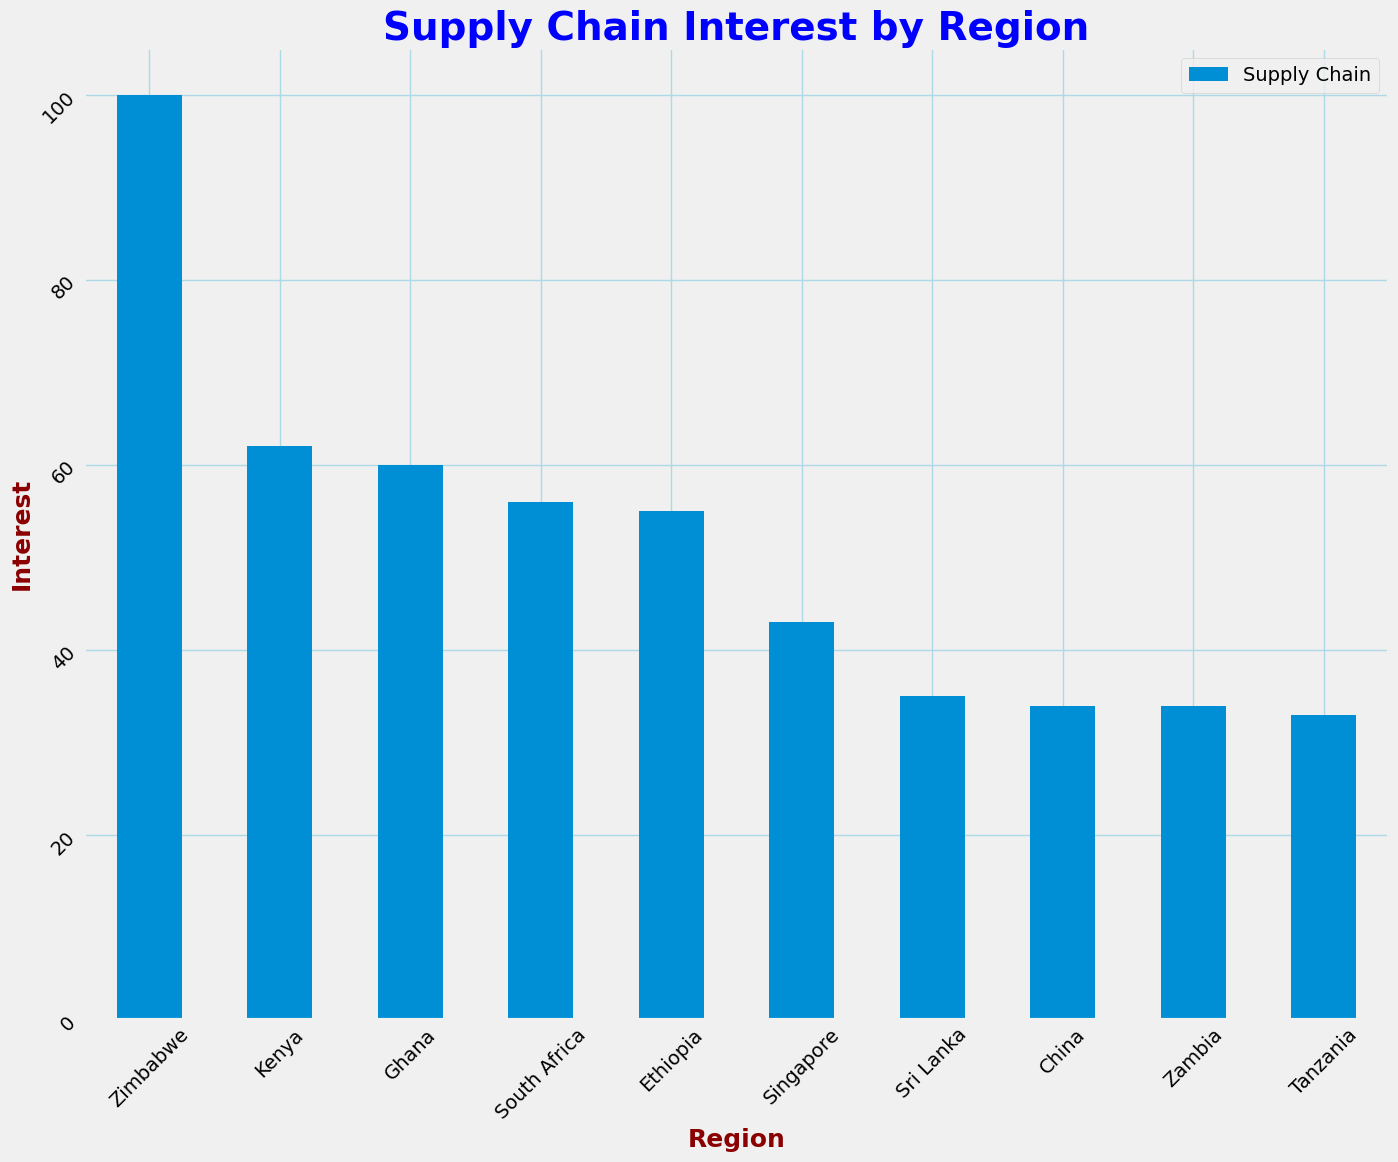

In [ ]:
# Plot a bar chart of the word that appears in each country
plt.figure(figsize=(15,12))
sup.reset_index().plot(x="geoName",
                        y="Supply Chain",
                        figsize=(15,12), kind="bar")
plt.style.use('fivethirtyeight')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.title("Supply Chain Interest by Region", fontsize = 28, color = 'blue',fontweight='bold')
plt.xlabel("Region", fontsize = 18, color = 'darkred',fontweight='bold')
plt.ylabel("Interest", fontsize = 18, color = 'darkred',fontweight='bold')
plt.grid(True, color = 'lightblue')
plt.show()

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


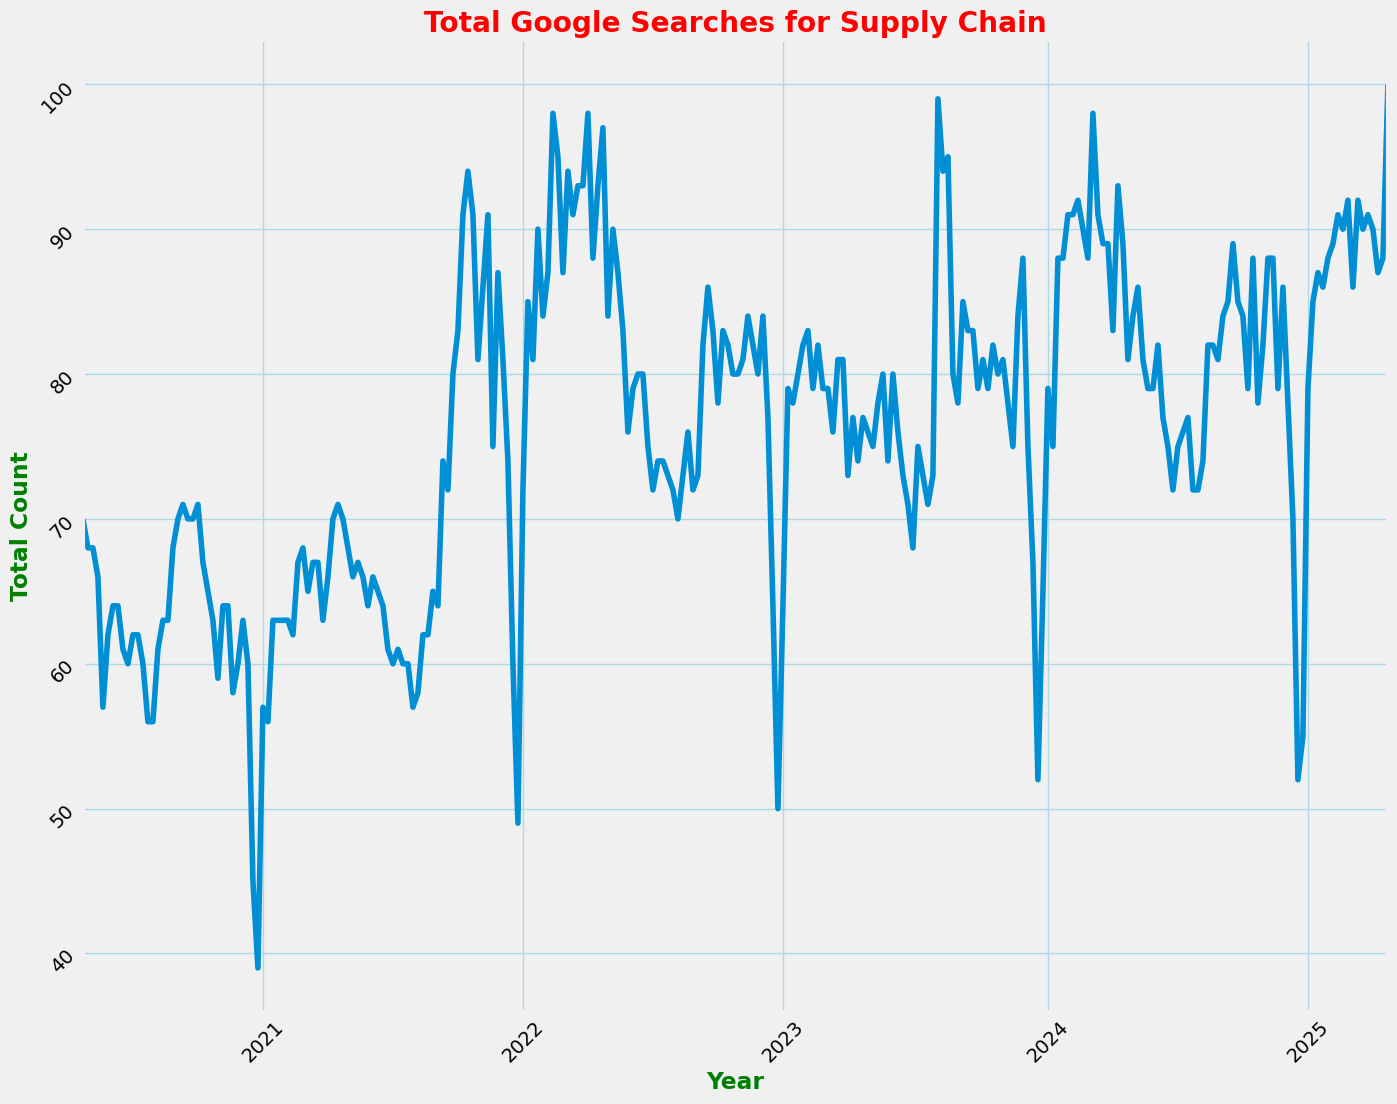

In [ ]:
# Plot a time series graph of the numer of times the word appears from 2020 to the current moment
sup = TrendReq(hl='en-US', tz=360)
sup.build_payload(kw_list=['Supply Chain'])
time.sleep(30)
try:
    sup = sup.interest_over_time()
except ResponseError as e:
    if e.response.status_code == 429:  # Check for TooManyRequestsError (HTTP 429)
        print("Too many requests. Retrying in 60 seconds...")
        time.sleep(60)
        sup = sup.interest_over_time() # Retry the request
    else:
        raise  # Re-raise the exception if it's not a TooManyRequestsError

fig, ax = plt.subplots(figsize=(15, 12))
sup['Supply Chain'].plot()
plt.style.use('fivethirtyeight')
plt.title('Total Google Searches for Supply Chain',
          fontweight='bold', color = 'red')
plt.xlabel('Year', color = 'green',fontweight='bold')
plt.ylabel('Total Count', color = 'green',fontweight='bold')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(True, color = 'lightblue')
plt.show()